### Cambio en las abundancias con acreción

Generando arreglo de masas desde 1g...
Calculando DM original (SBB)...


C:\Users\jaosi\AppData\Roaming\Python\Python313\site-packages\PBHBeta\functions.py:86: RuntimeWarning: invalid value encountered in scalar power
  Om_0 = beta0 * b * (1. - time / Delta_t) ** (1. / 3)


Vectorizando integraciones de acreción...
Calculando DM con Acreción (Campo Escalar)...


c:\Users\jaosi\Downloads\PBH Accretion\PBHpy\functionsaccret.py:228: RuntimeWarning: invalid value encountered in scalar power
  Om_0   = beta0 * b * (1. - time / Delta_t)**(1./3)


Graficando restricción de DM...


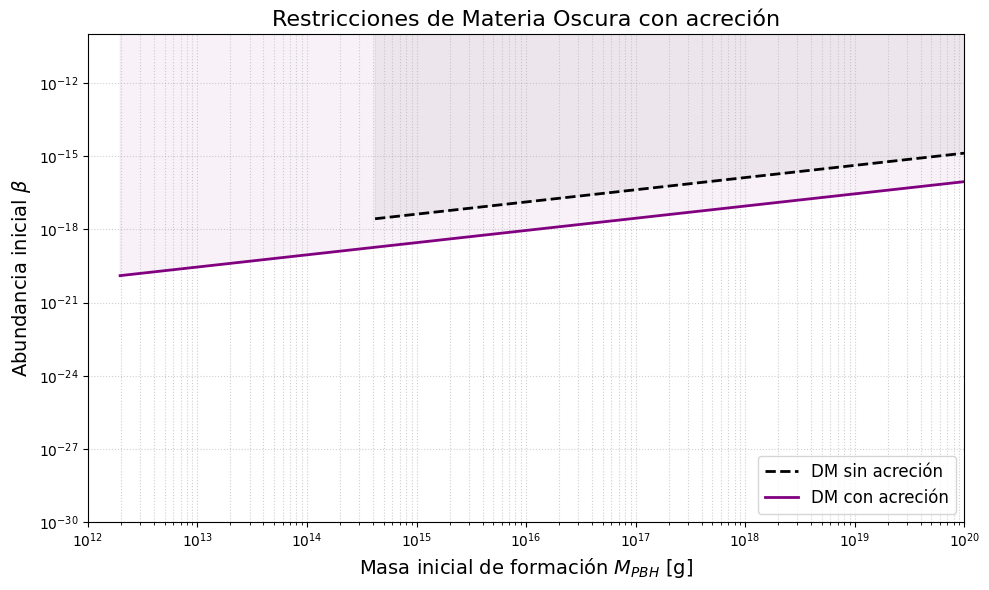

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import PBHBeta.functions as fn_orig
import functionsaccret as fn_new
from PBHBeta import constants

def comparar_solo_DM():
    print("Generando arreglo de masas desde 1g...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    omega = 0 # Radiación después del Reheating
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("Calculando DM original (SBB)...")
    from PBHBeta import constraints
    constraints.betas_DM_tot = [] # Limpiamos la memoria
    
    fn_orig.Betas_DM(M_tot, omega)
    betas_dm_orig = np.array(constraints.betas_DM_tot)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN (TU MODELO)
    # ---------------------------------------------------------
    print("Vectorizando integraciones de acreción...")
    constraints.betas_DM_tot = [] # Limpiamos de nuevo
    
    M_tot_jnp = jnp.array(M_tot) 
    M_f_tot_jnp, mu_tot_jnp = fn_new.precalcular_acreccion_lote(M_tot_jnp)
    
    M_f_tot = np.array(M_f_tot_jnp)
    mu_tot = np.array(mu_tot_jnp)
    
    print("Calculando DM con Acreción (Campo Escalar)...")
    fn_new.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    betas_dm_new = np.array(constraints.betas_DM_tot)
    
    # ---------------------------------------------------------
    # 3. LIMPIEZA Y GRAFICACIÓN
    # ---------------------------------------------------------
    # PBHBeta usa valores "dummy" enormes (como 1e-5) cuando el PBH no es DM.
    # Filtramos cualquier valor mayor a 1e-10 convirtiéndolo en 'nan' para que desaparezca.
    betas_orig_clean = np.where(betas_dm_orig > 1e-10, np.nan, betas_dm_orig)
    betas_new_clean = np.where(betas_dm_new > 1e-10, np.nan, betas_dm_new)
    
    print("Graficando restricción de DM...")
    plt.figure(figsize=(10, 6))
    
    plt.plot(M_tot, betas_orig_clean, label="DM sin acreción", color="black", linestyle="--", lw=2)
    plt.plot(M_tot, betas_new_clean, label="DM con acreción", color="purple", lw=2)
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'Masa inicial de formación $M_{PBH}$ [g]', fontsize=14)
    plt.ylabel(r'Abundancia inicial $\beta$', fontsize=14)
    plt.title('Restricciones de Materia Oscura con acreción', fontsize=16)
    
    plt.fill_between(M_tot, betas_orig_clean, 1, color='gray', alpha=0.1)
    plt.fill_between(M_tot, betas_new_clean, 1, color='purple', alpha=0.05)
    
    # Rango donde habitan los PBH de Materia Oscura
    plt.ylim(1e-30, 1e-10)
    plt.xlim(1e12, 1e20) 
    
    plt.legend(fontsize=12, loc='lower right')
    plt.grid(True, which="both", ls=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    comparar_solo_DM()

1/5 - Generando arreglo cósmico de masas...
2/5 - Calculando las 7 restricciones del Modelo Estándar...
3/5 - Acelerador JAX: Precalculando acreción para todo el universo...
4/5 - Evaluando las 7 restricciones con el modelo de Acreción...
5/5 - Procesando gráfica final...
¡Listo! Mostrando gráfica...


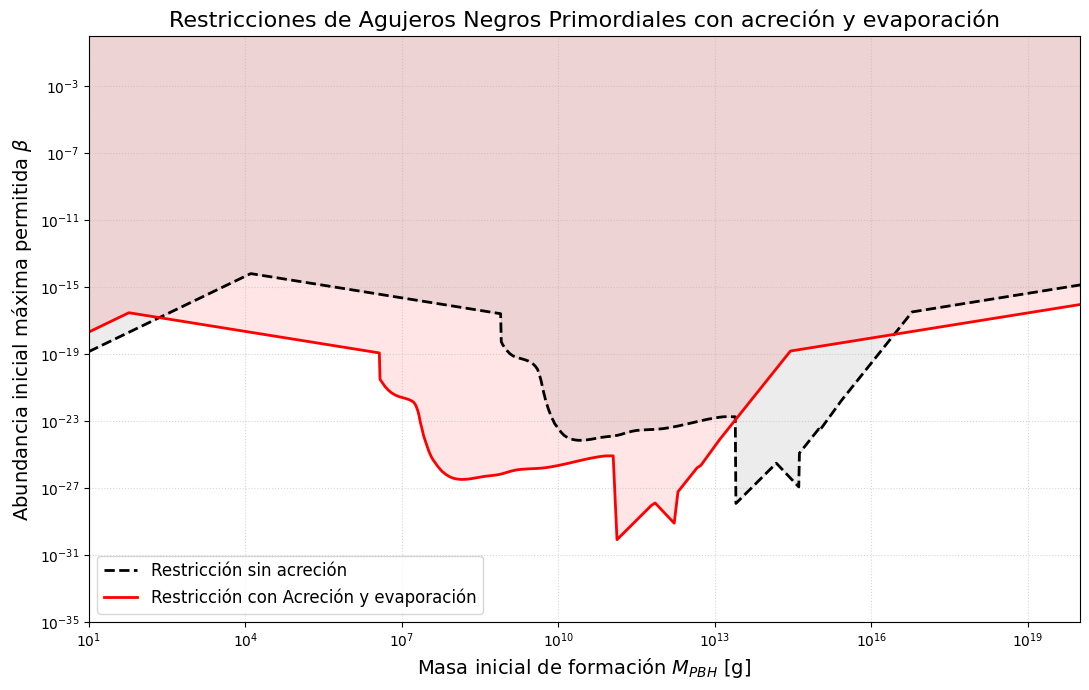

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

# Importamos las librerías
import PBHBeta.functions as fn_orig
import functionsaccret as fn_new
from PBHBeta import constants
from PBHBeta import constraints

def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def comparar_todas_las_restricciones():
    print("1/5 - Generando arreglo cósmico de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    
    # Época de Reheating dominada por materia
    omega = 0.0 
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("2/5 - Calculando las 7 restricciones del Modelo Estándar...")
    limpiar_memoria()
    
    fn_orig.Betas_DM(M_tot, omega)
    fn_orig.Betas_BBN(M_tot, omega)
    fn_orig.Betas_SD(M_tot, omega)
    fn_orig.Betas_CMB_AN(M_tot, omega)
    fn_orig.Betas_GRB(M_tot, omega)
    fn_orig.Betas_Reio(M_tot, omega)
    fn_orig.Betas_LSP(M_tot, omega)
    
    # Obtenemos la envolvente total (la restricción más fuerte)
    betas_orig_full = fn_orig.get_Betas_full(M_tot)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN (JAX)
    # ---------------------------------------------------------
    print("3/5 - Acelerador JAX: Precalculando acreción para todo el universo...")
    limpiar_memoria()
    
    M_tot_jnp = jnp.array(M_tot) 
    M_f_tot_jnp, mu_tot_jnp = fn_new.precalcular_acreccion_lote(M_tot_jnp)
    
    M_f_tot = np.array(M_f_tot_jnp)
    mu_tot = np.array(mu_tot_jnp)
    
    print("4/5 - Evaluando las 7 restricciones con el modelo de Acreción...")
    fn_new.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_SD(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    
    # Obtenemos la envolvente total con acreción
    betas_new_full = fn_new.get_Betas_full(M_tot)
    
    # ---------------------------------------------------------
    # 3. LIMPIEZA Y GRAFICACIÓN
    # ---------------------------------------------------------
    print("5/5 - Procesando gráfica final...")
    
    # Limpiamos los valores irreales para que matplotlib no dibuje líneas falsas
    betas_orig_clean = np.where(betas_orig_full == constants.ev1, np.nan, betas_orig_full)
    betas_new_clean = np.where(betas_new_full == constants.ev1, np.nan, betas_new_full)
    
    plt.figure(figsize=(11, 7))
    
    plt.plot(M_tot, betas_orig_clean, label="Restricción sin acreción", 
             color="black", linestyle="--", lw=2)
    plt.plot(M_tot, betas_new_clean, label="Restricción con Acreción y evaporación", 
             color="red", lw=2)
    
    # Sombreado para visualizar el espacio de parámetros prohibido
    plt.fill_between(M_tot, betas_orig_clean, 1, color='gray', alpha=0.15)
    plt.fill_between(M_tot, betas_new_clean, 1, color='red', alpha=0.1)
    
    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel(r'Masa inicial de formación $M_{PBH}$ [g]', fontsize=14)
    plt.ylabel(r'Abundancia inicial máxima permitida $\beta$', fontsize=14)
    plt.title('Restricciones de Agujeros Negros Primordiales con acreción y evaporación', fontsize=16)
    
    # Ajustamos la ventana para ver desde masas pequeñas hasta las gigantes
    plt.ylim(1e-35, 1e0)
    plt.xlim(1e1, 1e20) 
    
    plt.legend(fontsize=12, loc='lower left')
    plt.grid(True, which="both", ls=":", alpha=0.5)
    plt.tight_layout()
    
    print("¡Listo! Mostrando gráfica...")
    plt.show()

if __name__ == "__main__":
    comparar_todas_las_restricciones()


1/4 - Generando espacio de masas...
2/4 - Evaluando modelo Estándar...
3/4 - JAX: Calculando dinámica de acreción...
4/4 - Procesando gráfica comparativa...


C:\Users\jaosi\AppData\Local\Temp\ipykernel_20796\771502076.py:118: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(1e-35,0)


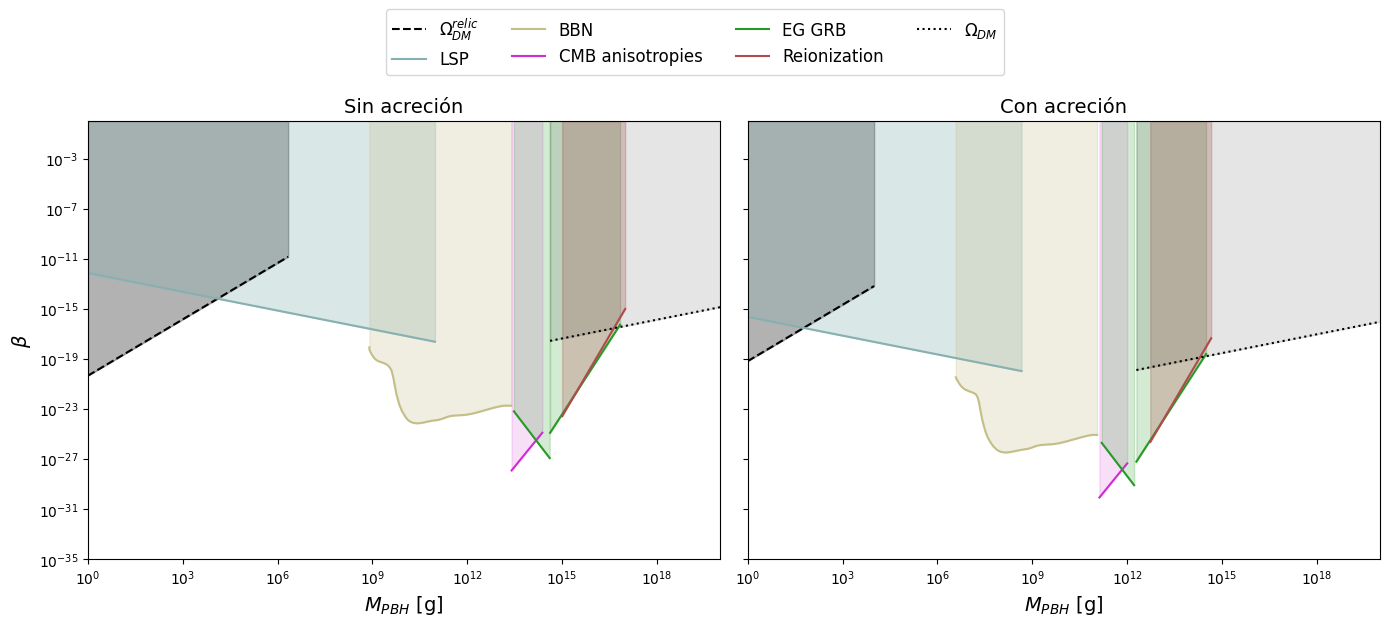

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

# Importamos las librerías
import PBHBeta.functions as fn_orig
import functionsaccret as fn_new
from PBHBeta import constants
from PBHBeta import constraints

def limpiar_memoria():
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def graficar_comparativa_espectros():
    print("1/4 - Generando espacio de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    omega = 0.0 # Reheating dominado por materia
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("2/4 - Evaluando modelo Estándar...")
    limpiar_memoria()
    M_dm_n_std, betas_dm_n_std, M_relic_std, betas_relic_std, _ = fn_orig.Betas_DM(M_tot, omega)
    M_lsp_std, betas_lsp_std, _ = fn_orig.Betas_LSP(M_tot, omega)
    M_bbn_std, betas_bbn_std, _ = fn_orig.Betas_BBN(M_tot, omega)
    M_cmb_std, betas_cmb_std, _ = fn_orig.Betas_CMB_AN(M_tot, omega)
    M_grb1_std, M_grb2_std, betas_grb1_std, betas_grb2_std, _, _ = fn_orig.Betas_GRB(M_tot, omega)
    M_reio_std, betas_reio_std, _ = fn_orig.Betas_Reio(M_tot, omega)

    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN (JAX)
    # ---------------------------------------------------------
    print("3/4 - JAX: Calculando dinámica de acreción...")
    limpiar_memoria()
    M_tot_jnp = jnp.array(M_tot) 
    M_f_tot_jnp, mu_tot_jnp = fn_new.precalcular_acreccion_lote(M_tot_jnp)
    
    M_f_tot = np.array(M_f_tot_jnp)
    mu_tot = np.array(mu_tot_jnp)
    
    M_dm_n_acc, betas_dm_n_acc, M_relic_acc, betas_relic_acc, _ = fn_new.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_lsp_acc, betas_lsp_acc, _ = fn_new.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_bbn_acc, betas_bbn_acc, _ = fn_new.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_cmb_acc, betas_cmb_acc, _ = fn_new.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_grb1_acc, M_grb2_acc, betas_grb1_acc, betas_grb2_acc, _, _ = fn_new.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_reio_acc, betas_reio_acc, _ = fn_new.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)

    # ---------------------------------------------------------
    # 3. GRAFICACIÓN PARALELA
    # ---------------------------------------------------------
    print("4/4 - Procesando gráfica comparativa...")
    
    # Creamos figura con 2 subplots que comparten el eje Y
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    colores = {
        'relic': 'black', 'lsp': '#87B0B0', 'bbn': '#C4BE88',
        'cmb': '#D12BD4', 'grb': '#279A25', 'reio': '#B14A4D', 'dm': 'black'
    }

    # Función auxiliar para graficar en un eje específico (ax)
    def plot_y_sombrear(ax, x, y, color, label, linestyle='-', alpha_fill=0.3):
        if len(x) > 0:
            line, = ax.plot(x, y, color=color, label=label, linestyle=linestyle, lw=1.5)
            ax.fill_between(x, y, 1.0, color=color, alpha=alpha_fill)
            return line
        return None

    # --- PANEL IZQUIERDO: ESTÁNDAR ---
    ax1.set_title("Sin acreción", fontsize=14)
    plot_y_sombrear(ax1, M_relic_std, betas_relic_std, colores['relic'], r'$\Omega_{DM}^{relic}$', linestyle='--')
    plot_y_sombrear(ax1, M_lsp_std, betas_lsp_std, colores['lsp'], 'LSP')
    plot_y_sombrear(ax1, M_bbn_std, betas_bbn_std, colores['bbn'], 'BBN', alpha_fill=0.25)
    plot_y_sombrear(ax1, M_cmb_std, betas_cmb_std, colores['cmb'], 'CMB anisotropies', alpha_fill=0.15)
    plot_y_sombrear(ax1, M_grb1_std, betas_grb1_std, colores['grb'], 'EG GRB', alpha_fill=0.2)
    if len(M_grb2_std) > 0:
        ax1.plot(M_grb2_std, betas_grb2_std, color=colores['grb'], lw=1.5)
        ax1.fill_between(M_grb2_std, betas_grb2_std, 1.0, color=colores['grb'], alpha=0.2)
    plot_y_sombrear(ax1, M_reio_std, betas_reio_std, colores['reio'], 'Reionization', alpha_fill=0.25)
    plot_y_sombrear(ax1, M_dm_n_std, betas_dm_n_std, colores['dm'], r'$\Omega_{DM}$', linestyle=':', alpha_fill=0.1)

    # --- PANEL DERECHO: CON ACRECIÓN ---
    ax2.set_title("Con acreción", fontsize=14)
    plot_y_sombrear(ax2, M_relic_acc, betas_relic_acc, colores['relic'], r'$\Omega_{DM}^{relic}$', linestyle='--')
    plot_y_sombrear(ax2, M_lsp_acc, betas_lsp_acc, colores['lsp'], 'LSP')
    plot_y_sombrear(ax2, M_bbn_acc, betas_bbn_acc, colores['bbn'], 'BBN', alpha_fill=0.25)
    plot_y_sombrear(ax2, M_cmb_acc, betas_cmb_acc, colores['cmb'], 'CMB anisotropies', alpha_fill=0.15)
    plot_y_sombrear(ax2, M_grb1_acc, betas_grb1_acc, colores['grb'], 'EG GRB', alpha_fill=0.2)
    if len(M_grb2_acc) > 0:
        ax2.plot(M_grb2_acc, betas_grb2_acc, color=colores['grb'], lw=1.5)
        ax2.fill_between(M_grb2_acc, betas_grb2_acc, 1.0, color=colores['grb'], alpha=0.2)
    plot_y_sombrear(ax2, M_reio_acc, betas_reio_acc, colores['reio'], 'Reionization', alpha_fill=0.25)
    plot_y_sombrear(ax2, M_dm_n_acc, betas_dm_n_acc, colores['dm'], r'$\Omega_{DM}$', linestyle=':', alpha_fill=0.1)

    # --- FORMATO DE EJES ---
    for ax in [ax1, ax2]:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M_{PBH}$ [g]', fontsize=14)
        ax.set_xlim(1e0, 1e20)
        ax.set_ylim(1e-30, 1e0)
    
    ax1.set_ylabel(r'$\beta$', fontsize=14)
    
    # --- LEYENDA GLOBAL (Centrada arriba) ---
    # Extraemos las etiquetas de ax1 para no duplicarlas
    handles, labels = ax1.get_legend_handles_labels()
    
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05),
               ncol=4, fontsize=12, frameon=True)
    plt.ylim(1e-35,0)
    plt.tight_layout()
    # Ajustamos para dejarle espacio a la leyenda global arriba
    fig.subplots_adjust(top=0.85) 
    
    plt.show()

if __name__ == "__main__":
    graficar_comparativa_espectros()

### Cambio en las abundancias con acreción y evaporación

c:\Users\jaosi\Downloads\PBH Accretion\PBHpy\functionscompleto.py:168: SyntaxWarning: invalid escape sequence '\O'
  focus on solving Eq.(10) with the constraint $\Omega_{PBH} = (m_{Pl}/M_{PBH})\beta(M_{PBH})$."""


Generando arreglo de masas desde 1g...
Calculando DM original (SBB)...
Vectorizando integraciones de acreción...
Calculando DM con Acreción (Campo Escalar)...


c:\Users\jaosi\Downloads\PBH Accretion\PBHpy\functionscompleto.py:193: RuntimeWarning: invalid value encountered in scalar power
  Om_0 = beta0 * b * (1. - time / Delta_t) ** (1. / 3)


Graficando restricción de DM...


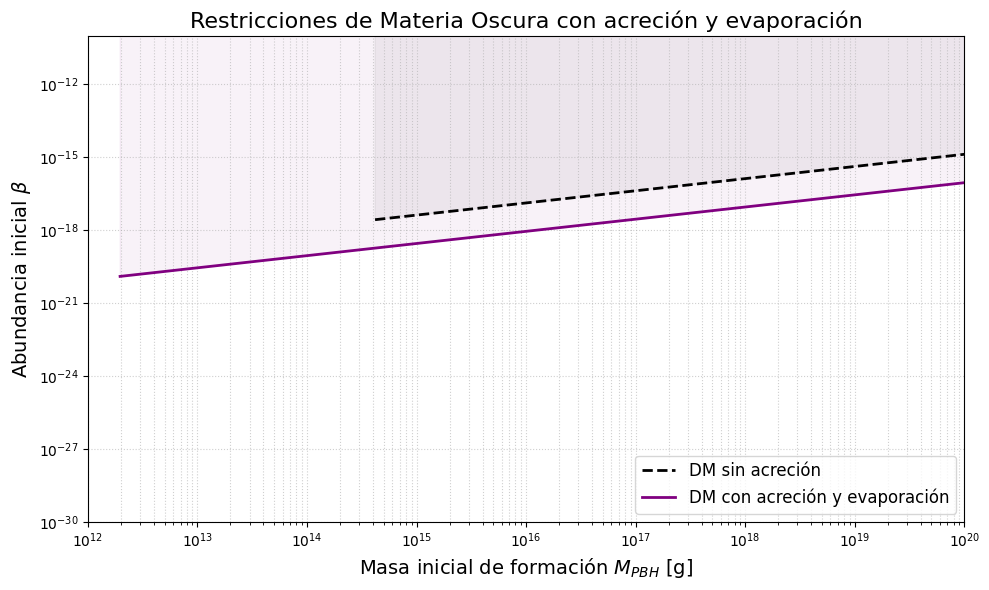

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import PBHBeta.functions as fn_orig
import functionscompleto as fn_new
from PBHBeta import constants

def comparar_solo_DM():
    print("Generando arreglo de masas desde 1g...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    omega = 0 # Radiación después del Reheating
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("Calculando DM original (SBB)...")
    from PBHBeta import constraints
    constraints.betas_DM_tot = [] # Limpiamos la memoria
    
    fn_orig.Betas_DM(M_tot, omega)
    betas_dm_orig = np.array(constraints.betas_DM_tot)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN (TU MODELO)
    # ---------------------------------------------------------
    print("Vectorizando integraciones de acreción...")
    constraints.betas_DM_tot = [] # Limpiamos de nuevo
    
    M_tot_jnp = jnp.array(M_tot) 
    M_f_tot_jnp, mu_tot_jnp = fn_new.precalcular_acreccion_lote(M_tot_jnp)
    
    M_f_tot = np.array(M_f_tot_jnp)
    mu_tot = np.array(mu_tot_jnp)
    
    print("Calculando DM con Acreción (Campo Escalar)...")
    fn_new.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    betas_dm_new = np.array(constraints.betas_DM_tot)
    
    # ---------------------------------------------------------
    # 3. LIMPIEZA Y GRAFICACIÓN
    # ---------------------------------------------------------
    # PBHBeta usa valores "dummy" enormes (como 1e-5) cuando el PBH no es DM.
    # Filtramos cualquier valor mayor a 1e-10 convirtiéndolo en 'nan' para que desaparezca.
    betas_orig_clean = np.where(betas_dm_orig > 1e-10, np.nan, betas_dm_orig)
    betas_new_clean = np.where(betas_dm_new > 1e-10, np.nan, betas_dm_new)
    
    print("Graficando restricción de DM...")
    plt.figure(figsize=(10, 6))
    
    plt.plot(M_tot, betas_orig_clean, label="DM sin acreción", color="black", linestyle="--", lw=2)
    plt.plot(M_tot, betas_new_clean, label="DM con acreción y evaporación", color="purple", lw=2)
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'Masa inicial de formación $M_{PBH}$ [g]', fontsize=14)
    plt.ylabel(r'Abundancia inicial $\beta$', fontsize=14)
    plt.title('Restricciones de Materia Oscura con acreción y evaporación', fontsize=16)
    
    plt.fill_between(M_tot, betas_orig_clean, 1, color='gray', alpha=0.1)
    plt.fill_between(M_tot, betas_new_clean, 1, color='purple', alpha=0.05)
    
    # Rango donde habitan los PBH de Materia Oscura
    plt.ylim(1e-30, 1e-10)
    plt.xlim(1e12, 1e20) 
    
    plt.legend(fontsize=12, loc='lower right')
    plt.grid(True, which="both", ls=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    comparar_solo_DM()

1/5 - Generando arreglo cósmico de masas...
2/5 - Calculando las 7 restricciones del Modelo Estándar...
3/5 - Acelerador JAX: Precalculando acreción para todo el universo...
4/5 - Evaluando las 7 restricciones con el modelo de Acreción...
5/5 - Procesando gráfica final...
¡Listo! Mostrando gráfica...


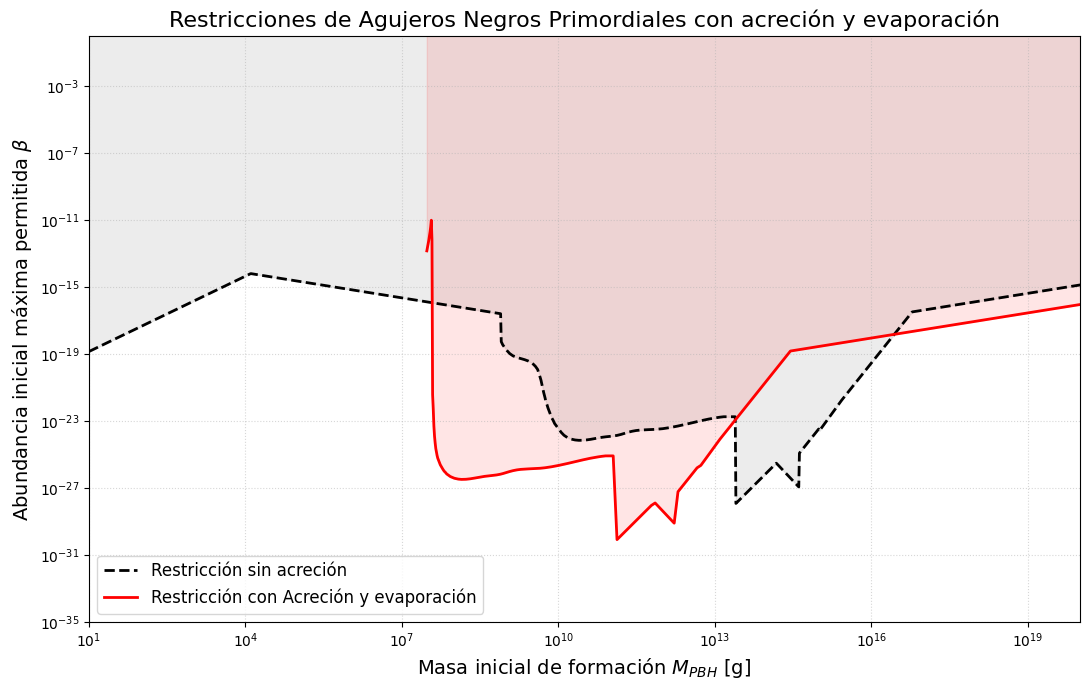

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

# Importamos las librerías
import PBHBeta.functions as fn_orig
import functionscompleto as fn_new
from PBHBeta import constants
from PBHBeta import constraints

def limpiar_memoria():
    """Limpia las variables globales de PBHBeta para evitar que los modelos se mezclen."""
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def comparar_todas_las_restricciones():
    print("1/5 - Generando arreglo cósmico de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    
    # Época de Reheating dominada por materia
    omega = 0.0 
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("2/5 - Calculando las 7 restricciones del Modelo Estándar...")
    limpiar_memoria()
    
    fn_orig.Betas_DM(M_tot, omega)
    fn_orig.Betas_BBN(M_tot, omega)
    fn_orig.Betas_SD(M_tot, omega)
    fn_orig.Betas_CMB_AN(M_tot, omega)
    fn_orig.Betas_GRB(M_tot, omega)
    fn_orig.Betas_Reio(M_tot, omega)
    fn_orig.Betas_LSP(M_tot, omega)
    
    # Obtenemos la envolvente total (la restricción más fuerte)
    betas_orig_full = fn_orig.get_Betas_full(M_tot)
    
    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN (JAX)
    # ---------------------------------------------------------
    print("3/5 - Acelerador JAX: Precalculando acreción para todo el universo...")
    limpiar_memoria()
    
    M_tot_jnp = jnp.array(M_tot) 
    M_f_tot_jnp, mu_tot_jnp = fn_new.precalcular_acreccion_lote(M_tot_jnp)
    
    M_f_tot = np.array(M_f_tot_jnp)
    mu_tot = np.array(mu_tot_jnp)
    
    print("4/5 - Evaluando las 7 restricciones con el modelo de Acreción...")
    fn_new.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_SD(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    fn_new.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    
    # Obtenemos la envolvente total con acreción
    betas_new_full = fn_new.get_Betas_full(M_tot)
    
    # ---------------------------------------------------------
    # 3. LIMPIEZA Y GRAFICACIÓN
    # ---------------------------------------------------------
    print("5/5 - Procesando gráfica final...")
    
    # Limpiamos los valores irreales para que matplotlib no dibuje líneas falsas
    betas_orig_clean = np.where(betas_orig_full == constants.ev1, np.nan, betas_orig_full)
    betas_new_clean = np.where(betas_new_full == constants.ev1, np.nan, betas_new_full)
    
    plt.figure(figsize=(11, 7))
    
    plt.plot(M_tot, betas_orig_clean, label="Restricción sin acreción", 
             color="black", linestyle="--", lw=2)
    plt.plot(M_tot, betas_new_clean, label="Restricción con Acreción y evaporación", 
             color="red", lw=2)
    
    # Sombreado para visualizar el espacio de parámetros prohibido
    plt.fill_between(M_tot, betas_orig_clean, 1, color='gray', alpha=0.15)
    plt.fill_between(M_tot, betas_new_clean, 1, color='red', alpha=0.1)
    
    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel(r'Masa inicial de formación $M_{PBH}$ [g]', fontsize=14)
    plt.ylabel(r'Abundancia inicial máxima permitida $\beta$', fontsize=14)
    plt.title('Restricciones de Agujeros Negros Primordiales con acreción y evaporación', fontsize=16)
    
    # Ajustamos la ventana para ver desde masas pequeñas hasta las gigantes
    plt.ylim(1e-35, 1e0)
    plt.xlim(1e1, 1e20) 
    
    plt.legend(fontsize=12, loc='lower left')
    plt.grid(True, which="both", ls=":", alpha=0.5)
    plt.tight_layout()
    
    print("¡Listo! Mostrando gráfica...")
    plt.show()

if __name__ == "__main__":
    comparar_todas_las_restricciones()

1/4 - Generando espacio de masas...
2/4 - Evaluando modelo Estándar...
3/4 - JAX: Calculando dinámica de acreción...
4/4 - Procesando gráfica comparativa...


C:\Users\jaosi\AppData\Local\Temp\ipykernel_20796\2197758709.py:118: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(1e-35,0)


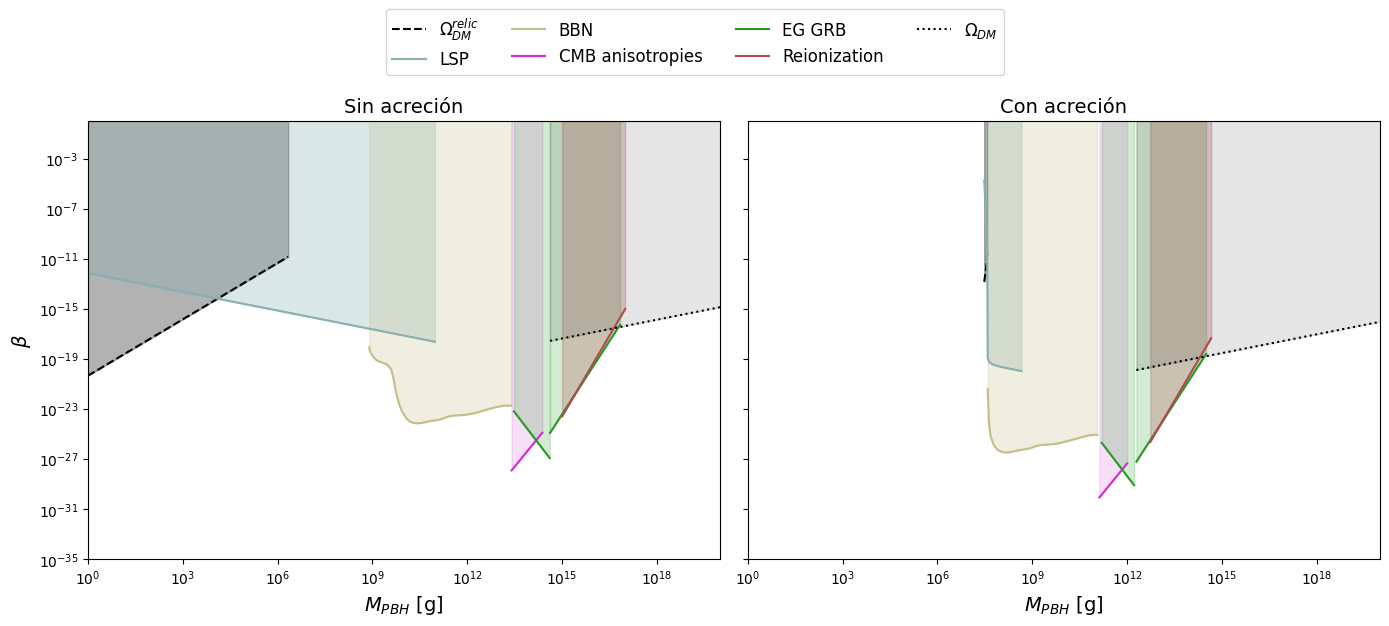

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

# Importamos las librerías
import PBHBeta.functions as fn_orig
import functionscompleto as fn_new
from PBHBeta import constants
from PBHBeta import constraints

def limpiar_memoria():
    constraints.betas_DM_tot = []
    constraints.betas_BBN_tot = []
    constraints.betas_SD_tot = []
    constraints.betas_CMB_AN_tot = []
    constraints.betas_GRB_tot = []
    constraints.betas_Reio_tot = []
    constraints.betas_LSP_tot = []

def graficar_comparativa_espectros():
    print("1/4 - Generando espacio de masas...")
    M_tot = fn_orig.put_M_array(1.0, 1e20)
    omega = 0.0 # Reheating dominado por materia
    
    # ---------------------------------------------------------
    # 1. CÁLCULO DEL MODELO ESTÁNDAR (SBB)
    # ---------------------------------------------------------
    print("2/4 - Evaluando modelo Estándar...")
    limpiar_memoria()
    M_dm_n_std, betas_dm_n_std, M_relic_std, betas_relic_std, _ = fn_orig.Betas_DM(M_tot, omega)
    M_lsp_std, betas_lsp_std, _ = fn_orig.Betas_LSP(M_tot, omega)
    M_bbn_std, betas_bbn_std, _ = fn_orig.Betas_BBN(M_tot, omega)
    M_cmb_std, betas_cmb_std, _ = fn_orig.Betas_CMB_AN(M_tot, omega)
    M_grb1_std, M_grb2_std, betas_grb1_std, betas_grb2_std, _, _ = fn_orig.Betas_GRB(M_tot, omega)
    M_reio_std, betas_reio_std, _ = fn_orig.Betas_Reio(M_tot, omega)

    # ---------------------------------------------------------
    # 2. CÁLCULO CON ACRECIÓN (JAX)
    # ---------------------------------------------------------
    print("3/4 - JAX: Calculando dinámica de acreción...")
    limpiar_memoria()
    M_tot_jnp = jnp.array(M_tot) 
    M_f_tot_jnp, mu_tot_jnp = fn_new.precalcular_acreccion_lote(M_tot_jnp)
    
    M_f_tot = np.array(M_f_tot_jnp)
    mu_tot = np.array(mu_tot_jnp)
    
    M_dm_n_acc, betas_dm_n_acc, M_relic_acc, betas_relic_acc, _ = fn_new.Betas_DM(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_lsp_acc, betas_lsp_acc, _ = fn_new.Betas_LSP(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_bbn_acc, betas_bbn_acc, _ = fn_new.Betas_BBN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_cmb_acc, betas_cmb_acc, _ = fn_new.Betas_CMB_AN(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_grb1_acc, M_grb2_acc, betas_grb1_acc, betas_grb2_acc, _, _ = fn_new.Betas_GRB(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)
    M_reio_acc, betas_reio_acc, _ = fn_new.Betas_Reio(M_tot, omega, M_f_tot=M_f_tot, mu_tot=mu_tot)

    # ---------------------------------------------------------
    # 3. GRAFICACIÓN PARALELA
    # ---------------------------------------------------------
    print("4/4 - Procesando gráfica comparativa...")
    
    # Creamos figura con 2 subplots que comparten el eje Y
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    colores = {
        'relic': 'black', 'lsp': '#87B0B0', 'bbn': '#C4BE88',
        'cmb': '#D12BD4', 'grb': '#279A25', 'reio': '#B14A4D', 'dm': 'black'
    }

    # Función auxiliar para graficar en un eje específico (ax)
    def plot_y_sombrear(ax, x, y, color, label, linestyle='-', alpha_fill=0.3):
        if len(x) > 0:
            line, = ax.plot(x, y, color=color, label=label, linestyle=linestyle, lw=1.5)
            ax.fill_between(x, y, 1.0, color=color, alpha=alpha_fill)
            return line
        return None

    # --- PANEL IZQUIERDO: ESTÁNDAR ---
    ax1.set_title("Sin acreción", fontsize=14)
    plot_y_sombrear(ax1, M_relic_std, betas_relic_std, colores['relic'], r'$\Omega_{DM}^{relic}$', linestyle='--')
    plot_y_sombrear(ax1, M_lsp_std, betas_lsp_std, colores['lsp'], 'LSP')
    plot_y_sombrear(ax1, M_bbn_std, betas_bbn_std, colores['bbn'], 'BBN', alpha_fill=0.25)
    plot_y_sombrear(ax1, M_cmb_std, betas_cmb_std, colores['cmb'], 'CMB anisotropies', alpha_fill=0.15)
    plot_y_sombrear(ax1, M_grb1_std, betas_grb1_std, colores['grb'], 'EG GRB', alpha_fill=0.2)
    if len(M_grb2_std) > 0:
        ax1.plot(M_grb2_std, betas_grb2_std, color=colores['grb'], lw=1.5)
        ax1.fill_between(M_grb2_std, betas_grb2_std, 1.0, color=colores['grb'], alpha=0.2)
    plot_y_sombrear(ax1, M_reio_std, betas_reio_std, colores['reio'], 'Reionization', alpha_fill=0.25)
    plot_y_sombrear(ax1, M_dm_n_std, betas_dm_n_std, colores['dm'], r'$\Omega_{DM}$', linestyle=':', alpha_fill=0.1)

    # --- PANEL DERECHO: CON ACRECIÓN ---
    ax2.set_title("Con acreción", fontsize=14)
    plot_y_sombrear(ax2, M_relic_acc, betas_relic_acc, colores['relic'], r'$\Omega_{DM}^{relic}$', linestyle='--')
    plot_y_sombrear(ax2, M_lsp_acc, betas_lsp_acc, colores['lsp'], 'LSP')
    plot_y_sombrear(ax2, M_bbn_acc, betas_bbn_acc, colores['bbn'], 'BBN', alpha_fill=0.25)
    plot_y_sombrear(ax2, M_cmb_acc, betas_cmb_acc, colores['cmb'], 'CMB anisotropies', alpha_fill=0.15)
    plot_y_sombrear(ax2, M_grb1_acc, betas_grb1_acc, colores['grb'], 'EG GRB', alpha_fill=0.2)
    if len(M_grb2_acc) > 0:
        ax2.plot(M_grb2_acc, betas_grb2_acc, color=colores['grb'], lw=1.5)
        ax2.fill_between(M_grb2_acc, betas_grb2_acc, 1.0, color=colores['grb'], alpha=0.2)
    plot_y_sombrear(ax2, M_reio_acc, betas_reio_acc, colores['reio'], 'Reionization', alpha_fill=0.25)
    plot_y_sombrear(ax2, M_dm_n_acc, betas_dm_n_acc, colores['dm'], r'$\Omega_{DM}$', linestyle=':', alpha_fill=0.1)

    # --- FORMATO DE EJES ---
    for ax in [ax1, ax2]:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M_{PBH}$ [g]', fontsize=14)
        ax.set_xlim(1e0, 1e20)
        ax.set_ylim(1e-30, 1e0)
    
    ax1.set_ylabel(r'$\beta$', fontsize=14)
    
    # --- LEYENDA GLOBAL (Centrada arriba) ---
    # Extraemos las etiquetas de ax1 para no duplicarlas
    handles, labels = ax1.get_legend_handles_labels()
    
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05),
               ncol=4, fontsize=12, frameon=True)
    plt.ylim(1e-35,0)
    plt.tight_layout()
    # Ajustamos para dejarle espacio a la leyenda global arriba
    fig.subplots_adjust(top=0.85) 
    
    plt.show()

if __name__ == "__main__":
    graficar_comparativa_espectros()